# Upsilon / SNIa-Fe-yield comparison (chemevo single-zone)

Single-zone analog of `/Users/honeyeah/Codes/VICE/Mn_metdepbestfit_comparison/plot_all_metdepbestfit.ipynb`,
which compares several VICE multizone runs that share the same metdep params
(from `grid_search_fine_v3`) but use different `Upsilon` (overall yield scale)
and SNIa Fe yield multiplier. This builds the same set of configurations as
chemevo single-zone models instead, using `build_model_df` and
`plot_mn_fe_vs_fe_mg` (same plotting as `plot_grid_search_fine_results.py`,
with `show_data=True` to overlay the real APOGEE points).

The SNIa Fe multiplier (1.1 / 1.2 / 1.3) maps to chemevo's `yields_ref`
presets `"W2024,moreFe"` / `"W2024,moreFe20"` / `"W2024,moreFe30"` -
verified against the VICE side's own yields module
(`src/simulations/yields/T26.py`: `vice.yields.sneia.settings["fe"] = 7.7e-4 * <mult> * Upsilon`,
exactly chemevo's formula). `"W2024,moreFe20"` (the 1.2 case) didn't exist
yet in `evolution_V1.py`'s yields table - added it alongside the existing
1.1/1.3 presets.

In [1]:
import matplotlib.pyplot as plt

from chemevo import iterative_1D_method
from chemevo.mn_fe_lines import load_mn_fe_lines
from chemevo.plotting import plot_mn_fe_vs_fe_mg
from chemevo import plotstyle

plotstyle.use()

In [2]:
# Settings grabbed directly from
# VICE/Mn_metdepbestfit_comparison/plot_all_metdepbestfit.ipynb's CONFIGS list.
# metdep params (alpha_cc, alpha_Ia, g_cc, g_ratio) are the same
# grid_search_fine_v3 best fit for every config there, so they're the same here.
CONFIGS = [
    dict(key="U2_etaT26", upsilon=2.0, yields_ref="W2024,moreFe", metdep=(0.22, 0.31, 0.26, 3.08)),
    dict(key="U1p27_etaT26", upsilon=1.2658, yields_ref="W2024,moreFe", metdep=(0.22, 0.31, 0.26, 3.08)),
    dict(key="U1p27_etaT26_mFe1p2", upsilon=1.2658, yields_ref="W2024,moreFe20", metdep=(0.22, 0.31, 0.26, 3.08)),
    dict(key="U1p27_etaT26_mFe1p3", upsilon=1.2658, yields_ref="W2024,moreFe30", metdep=(0.22, 0.31, 0.26, 3.08)),
    dict(key="U1_etaT26_mFe1p3", upsilon=1.0, yields_ref="W2024,moreFe30", metdep=(0.22, 0.31, 0.26, 3.08)),
]

lines_df = load_mn_fe_lines()

Loops over the 5 configs, building one chemevo single-zone model per config
and plotting it (with the real APOGEE points underneath) - one 5-panel
figure per config, scroll down to compare them.

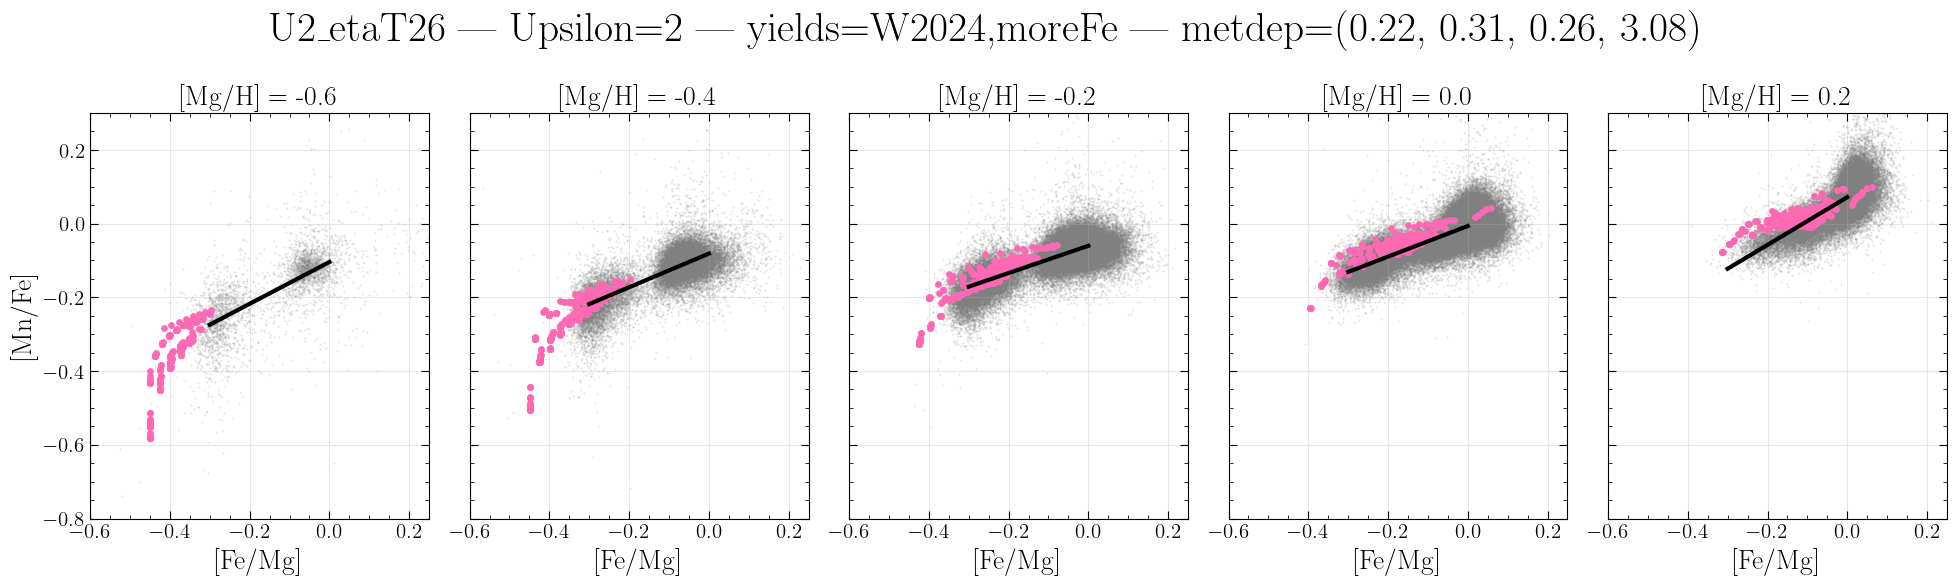

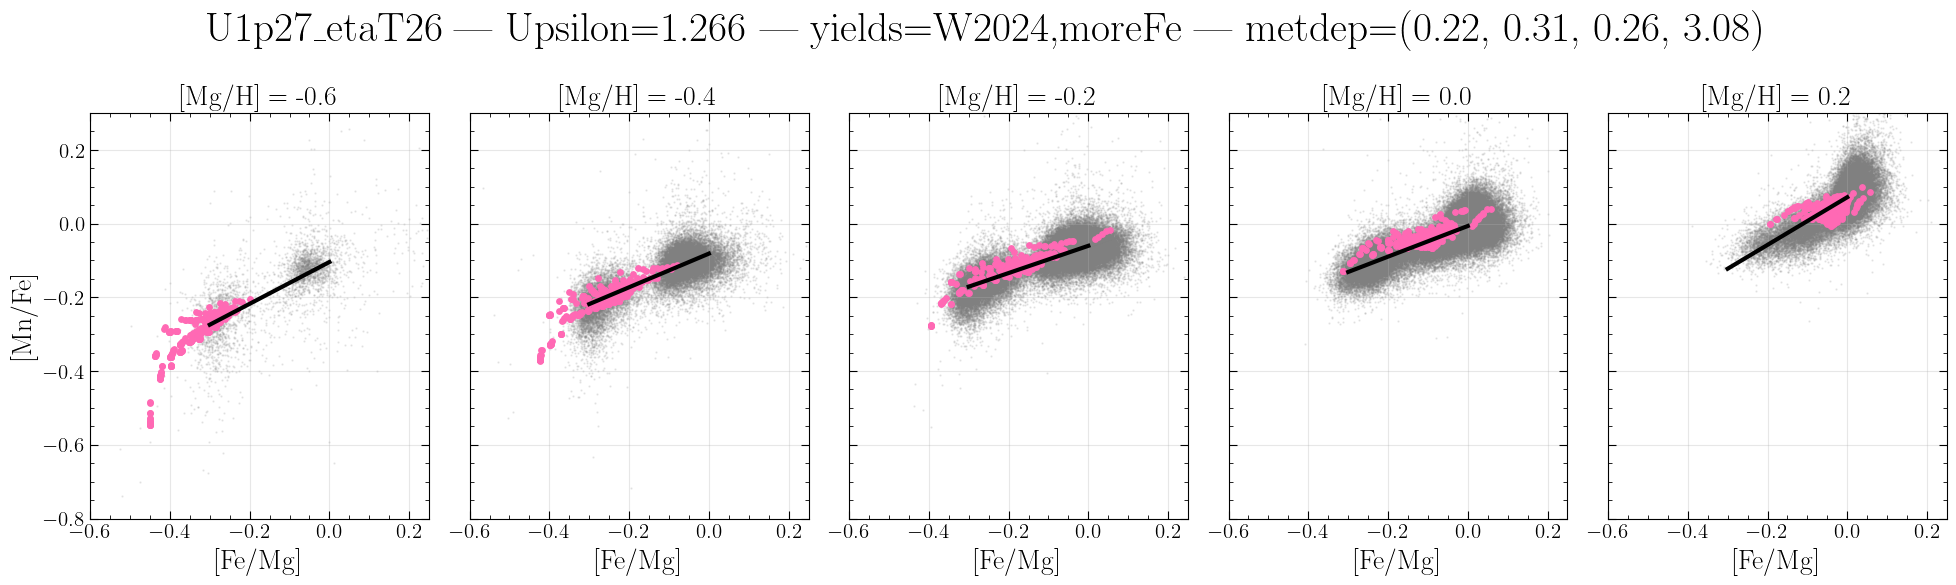

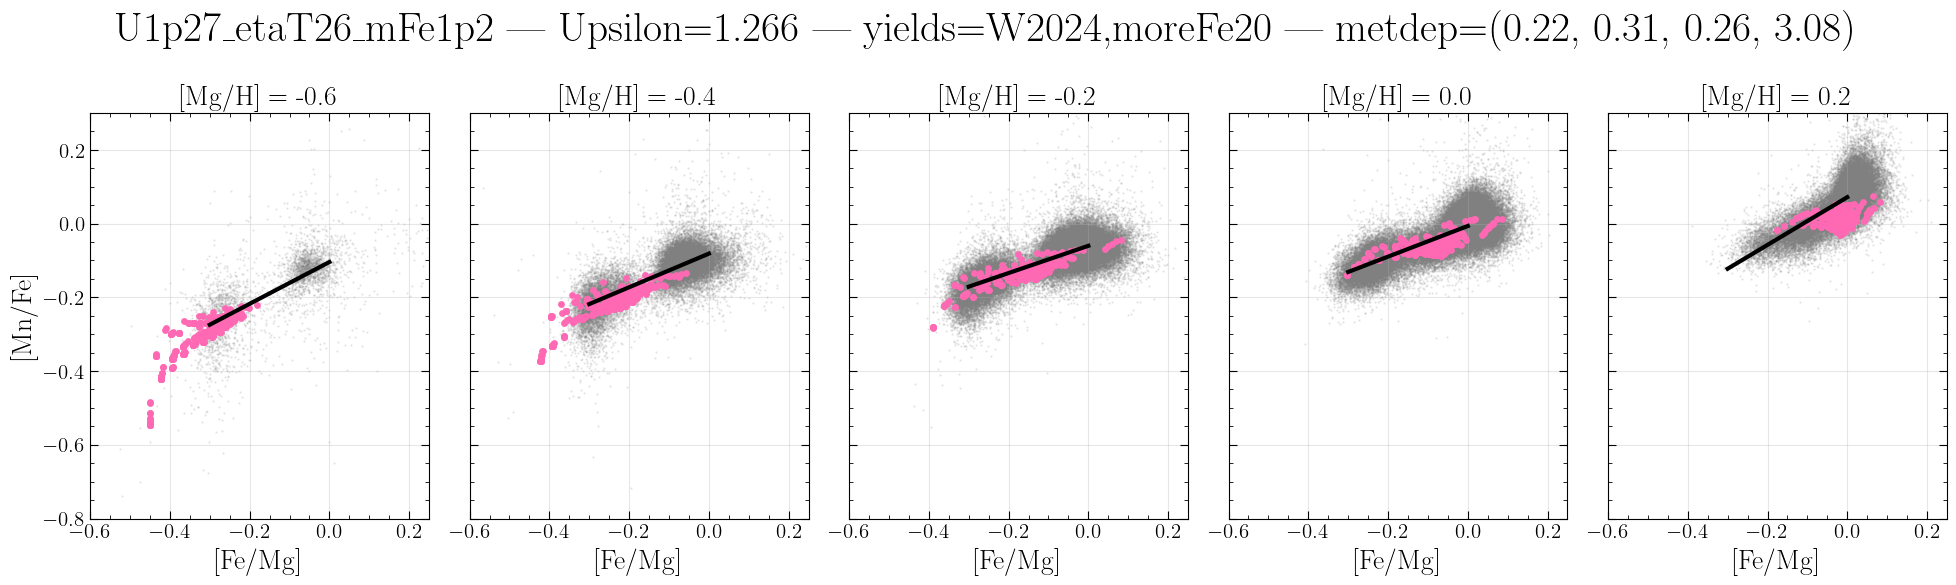

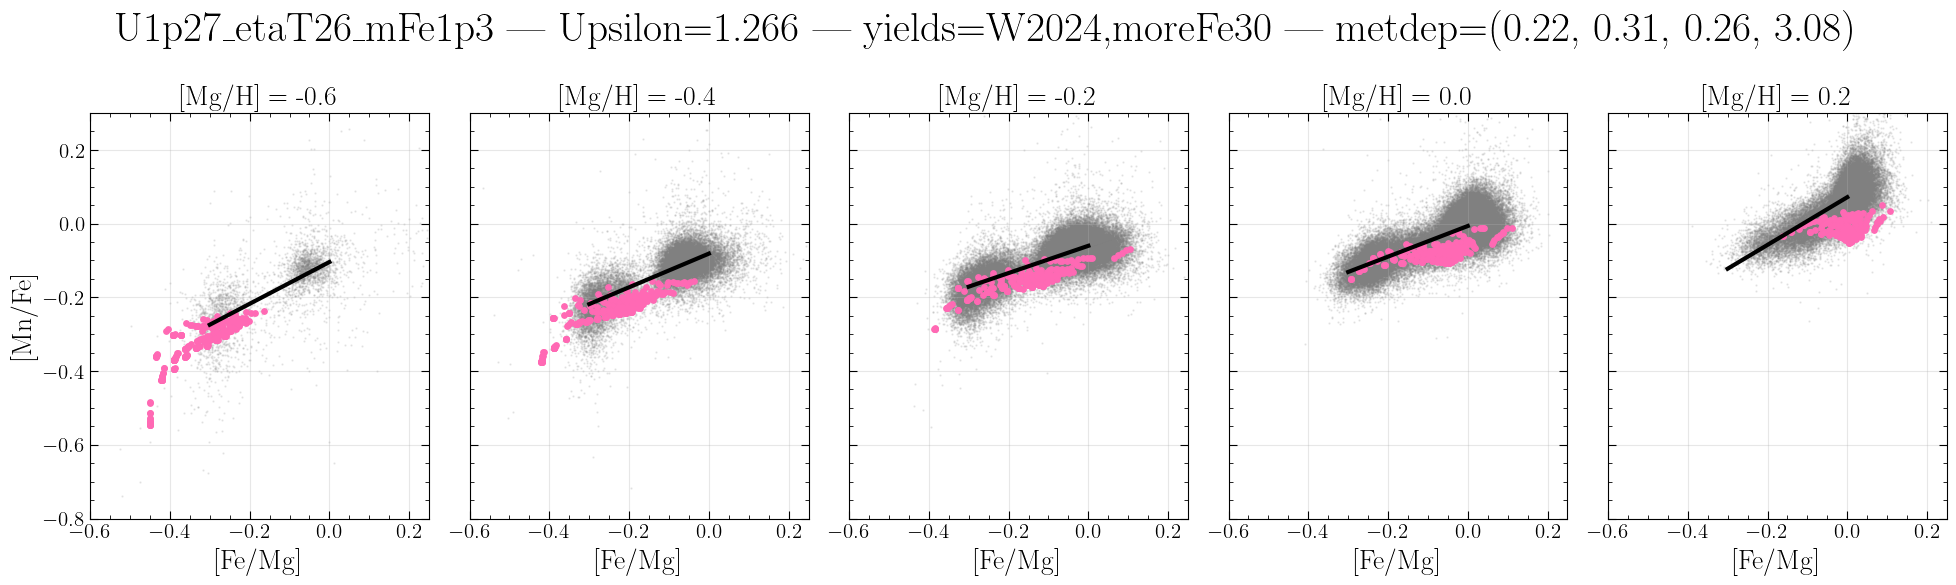

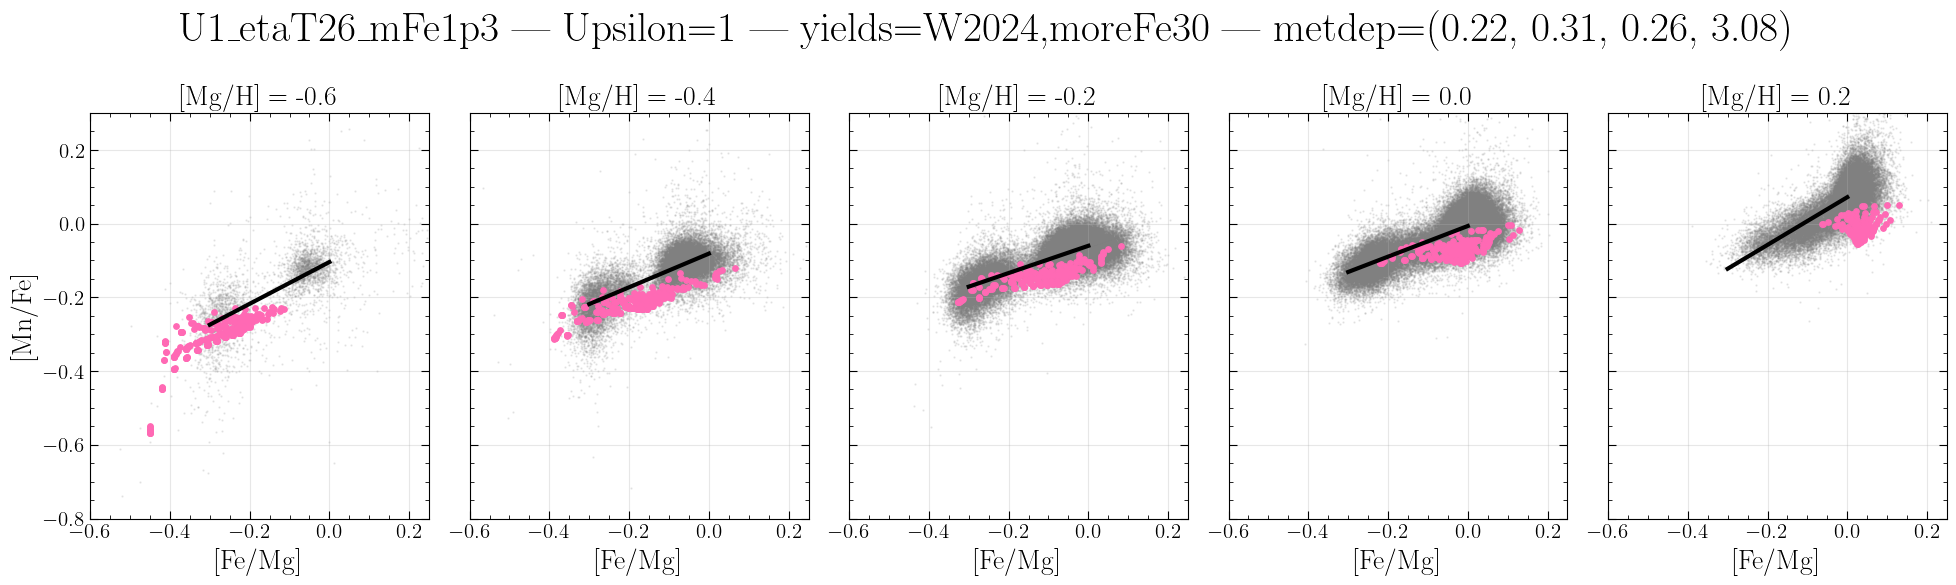

In [5]:
for cfg in CONFIGS:
    alpha_cc, alpha_Ia, g_cc, g_ratio = cfg["metdep"]

    model_df = iterative_1D_method.build_model_df(
        alpha_cc=alpha_cc, alpha_Ia=alpha_Ia, g_cc=g_cc, g_ratio=g_ratio,
        Upsilon=cfg["upsilon"], yields_ref=cfg["yields_ref"],
    )

    label = (
        f"{cfg['key']} | Upsilon={cfg['upsilon']:.4g} | yields={cfg['yields_ref']} | "
        f"metdep=({alpha_cc}, {alpha_Ia}, {g_cc}, {g_ratio})"
    )

    fig, axes = plot_mn_fe_vs_fe_mg({label: model_df}, lines_df, show_data=True, legend_on=0, color = 'hotpink')
    plt.show()